In [1]:
# import libraries and other configurations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
import dython
from scipy import stats
from dython.nominal import associations

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

warnings.filterwarnings("ignore")

RANDOM_STATE = 121
REDUNDANCY_THRESHOLD = 0.70

In [2]:
# Load cleaned dataset
df = pd.read_csv(
    "../data/processed/cleaned_donor_data.csv",
)

df.columns.tolist()

['donor_unique_id',
 'donor_postal_code',
 'donor_age',
 'gender_identity',
 'is_member_flag',
 'is_alumnus_flag',
 'is_parent_flag',
 'has_involvement_flag',
 'preferred_address_type',
 'has_email_flag',
 'consecutive_donor_years',
 'last_fiscal_year_donation',
 'donation_2_fiscal_years_ago',
 'donation_3_fiscal_years_ago',
 'donation_4_fiscal_years_ago',
 'donation_5_fiscal_years_ago',
 'current_fiscal_year_donation',
 'cumulative_donation_amount',
 'donor_indicator_flag']

In [3]:
# Verify dataset loaded correctly
print(f"Dataset Shape: {df.shape}")
df.sample(10, random_state=RANDOM_STATE)

Dataset Shape: (34403, 19)


,donor_unique_id,donor_postal_code,donor_age,gender_identity,is_member_flag,is_alumnus_flag,is_parent_flag,has_involvement_flag,preferred_address_type,has_email_flag,consecutive_donor_years,last_fiscal_year_donation,donation_2_fiscal_years_ago,donation_3_fiscal_years_ago,donation_4_fiscal_years_ago,donation_5_fiscal_years_ago,current_fiscal_year_donation,cumulative_donation_amount,donor_indicator_flag
33267,33371,42301.0,46,Female,0,0,0,0,Home,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
26595,26683,45620.0,42,Female,0,0,0,0,Home,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
16653,16704,33427.0,28,Female,0,0,0,0,Home,0,0,0.0,120.0,0.0,0.0,0.0,0.0,120.0,1
21428,21498,54131.0,33,Female,0,0,0,0,Home,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
16873,16924,90265.0,33,Male,0,1,0,0,Home,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
19919,19982,54459.0,32,Female,0,0,0,0,Home,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
15478,15527,64686.0,42,Male,0,0,0,0,Home,0,8,0.0,0.0,10.0,0.0,0.0,0.0,9680.0,1
591,596,12067.0,42,Female,0,0,1,0,Home,0,0,0.0,100.0,1.0,0.0,0.0,0.0,101.0,1
1474,1483,90265.0,42,Female,0,1,0,0,Home,1,0,0.0,0.0,0.0,0.0,0.0,0.0,479.0,1
22846,22922,45856.0,36,Female,0,0,0,0,Home,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [4]:
# Verify dataset data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34403 entries, 0 to 34402
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   donor_unique_id               34403 non-null  int64  
 1   donor_postal_code             34312 non-null  float64
 2   donor_age                     34403 non-null  int64  
 3   gender_identity               33912 non-null  str    
 4   is_member_flag                34403 non-null  int64  
 5   is_alumnus_flag               34403 non-null  int64  
 6   is_parent_flag                34403 non-null  int64  
 7   has_involvement_flag          34403 non-null  int64  
 8   preferred_address_type        30370 non-null  str    
 9   has_email_flag                34403 non-null  int64  
 10  consecutive_donor_years       34403 non-null  int64  
 11  last_fiscal_year_donation     34403 non-null  float64
 12  donation_2_fiscal_years_ago   34403 non-null  float64
 13  donation_3_f

In [5]:
# Data types summary
dtype_summary = (
    df.dtypes
      .astype(str)
      .value_counts()
      .reset_index()
      .style.hide(axis="index")
)

dtype_summary.columns = ["Data Type", "Count"]
dtype_summary

index,count
int64,9
float64,8
str,2


In [6]:
# Verify dataset missing values
missing_summary = (
    df.isna()
      .sum()
      .to_frame("Missing Count")
)

missing_summary["Missing %"] = (
    missing_summary["Missing Count"] / len(df) * 100
)

missing_summary = (
    missing_summary
      .sort_values("Missing Count", ascending=False)
)

missing_summary

,Missing Count,Missing %
preferred_address_type,4033,11.722815
gender_identity,491,1.427201
donor_postal_code,91,0.264512
donor_unique_id,0,0.000000
last_fiscal_year_donation,0,0.000000
cumulative_donation_amount,0,0.000000
current_fiscal_year_donation,0,0.000000
donation_5_fiscal_years_ago,0,0.000000
donation_4_fiscal_years_ago,0,0.000000
donation_3_fiscal_years_ago,0,0.000000


## Dataset Overview

The finalized cleaned analytical dataset was successfully loaded and verified for Dython analysis. The dataset contains **34,403 donor records** and **19 features**, consistent with the dataset used throughout Phase 2. Data types and missing values match expectations from the data cleaning process, and all required libraries were successfully imported. The environment is now prepared for mixed-type association analysis.

In [7]:
# Define feature groups
numeric_features = [
    "donor_age",
    "consecutive_donor_years",
    "last_fiscal_year_donation",
    "donation_2_fiscal_years_ago",
    "donation_3_fiscal_years_ago",
    "donation_4_fiscal_years_ago",
    "donation_5_fiscal_years_ago",
    "current_fiscal_year_donation",
    "cumulative_donation_amount"
]

categorical_features = [
    "gender_identity",
    "preferred_address_type"
]

binary_features = [
    "is_alumnus_flag",
    "is_parent_flag",
    "has_involvement_flag",
    "has_email_flag"
]

target_feature = [
    "donor_indicator_flag"
]

In [8]:
# Variable classification summary
association_features = (
    numeric_features
    + categorical_features
    + binary_features
    + target_feature
)

variable_summary = pd.DataFrame({
    "Variable": association_features,
    "Category": (
        ["Numeric"] * len(numeric_features)
        + ["Categorical"] * len(categorical_features)
        + ["Binary"] * len(binary_features)
        + ["Target"]
    )
})

variable_summary.style.hide(axis="index")

Variable,Category
donor_age,Numeric
consecutive_donor_years,Numeric
last_fiscal_year_donation,Numeric
donation_2_fiscal_years_ago,Numeric
donation_3_fiscal_years_ago,Numeric
donation_4_fiscal_years_ago,Numeric
donation_5_fiscal_years_ago,Numeric
current_fiscal_year_donation,Numeric
cumulative_donation_amount,Numeric
gender_identity,Categorical


In [9]:
# Verify selected features exist in the dataset
missing_features = [col for col in association_features if col not in df.columns]

if missing_features:
    print("Missing features:")
    print(missing_features)
else:
    print("All selected features are present in the dataset.")

All selected features are present in the dataset.


In [10]:
# Create analysis dataset for dython analysis
association_df = df[association_features].copy()

print(f"Association Dataset Shape: {association_df.shape}")

association_df.sample(10, random_state=RANDOM_STATE)

Association Dataset Shape: (34403, 16)


,donor_age,consecutive_donor_years,last_fiscal_year_donation,donation_2_fiscal_years_ago,donation_3_fiscal_years_ago,donation_4_fiscal_years_ago,donation_5_fiscal_years_ago,current_fiscal_year_donation,cumulative_donation_amount,gender_identity,preferred_address_type,is_alumnus_flag,is_parent_flag,has_involvement_flag,has_email_flag,donor_indicator_flag
33267,46,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Female,Home,0,0,0,0,0
26595,42,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Female,Home,0,0,0,0,0
16653,28,0,0.0,120.0,0.0,0.0,0.0,0.0,120.0,Female,Home,0,0,0,0,1
21428,33,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Female,Home,0,0,0,0,1
16873,33,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Male,Home,1,0,0,0,0
19919,32,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Female,Home,0,0,0,0,0
15478,42,8,0.0,0.0,10.0,0.0,0.0,0.0,9680.0,Male,Home,0,0,0,0,1
591,42,0,0.0,100.0,1.0,0.0,0.0,0.0,101.0,Female,Home,0,1,0,0,1
1474,42,0,0.0,0.0,0.0,0.0,0.0,0.0,479.0,Female,Home,1,0,0,1,1
22846,36,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Female,Home,0,0,0,0,0


In [11]:
# Verify analysis dataset
association_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34403 entries, 0 to 34402
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   donor_age                     34403 non-null  int64  
 1   consecutive_donor_years       34403 non-null  int64  
 2   last_fiscal_year_donation     34403 non-null  float64
 3   donation_2_fiscal_years_ago   34403 non-null  float64
 4   donation_3_fiscal_years_ago   34403 non-null  float64
 5   donation_4_fiscal_years_ago   34403 non-null  float64
 6   donation_5_fiscal_years_ago   34403 non-null  float64
 7   current_fiscal_year_donation  34403 non-null  float64
 8   cumulative_donation_amount    34403 non-null  float64
 9   gender_identity               33912 non-null  str    
 10  preferred_address_type        30370 non-null  str    
 11  is_alumnus_flag               34403 non-null  int64  
 12  is_parent_flag                34403 non-null  int64  
 13  has_involvem

In [12]:
# Verify analysis dataset
association_df.nunique().sort_values()

is_alumnus_flag                    2
is_parent_flag                     2
has_involvement_flag               2
has_email_flag                     2
donor_indicator_flag               2
gender_identity                    3
preferred_address_type             4
consecutive_donor_years           33
donor_age                         88
current_fiscal_year_donation     165
donation_4_fiscal_years_ago      177
donation_5_fiscal_years_ago      182
last_fiscal_year_donation        188
donation_3_fiscal_years_ago      188
donation_2_fiscal_years_ago      189
cumulative_donation_amount      1592
dtype: int64

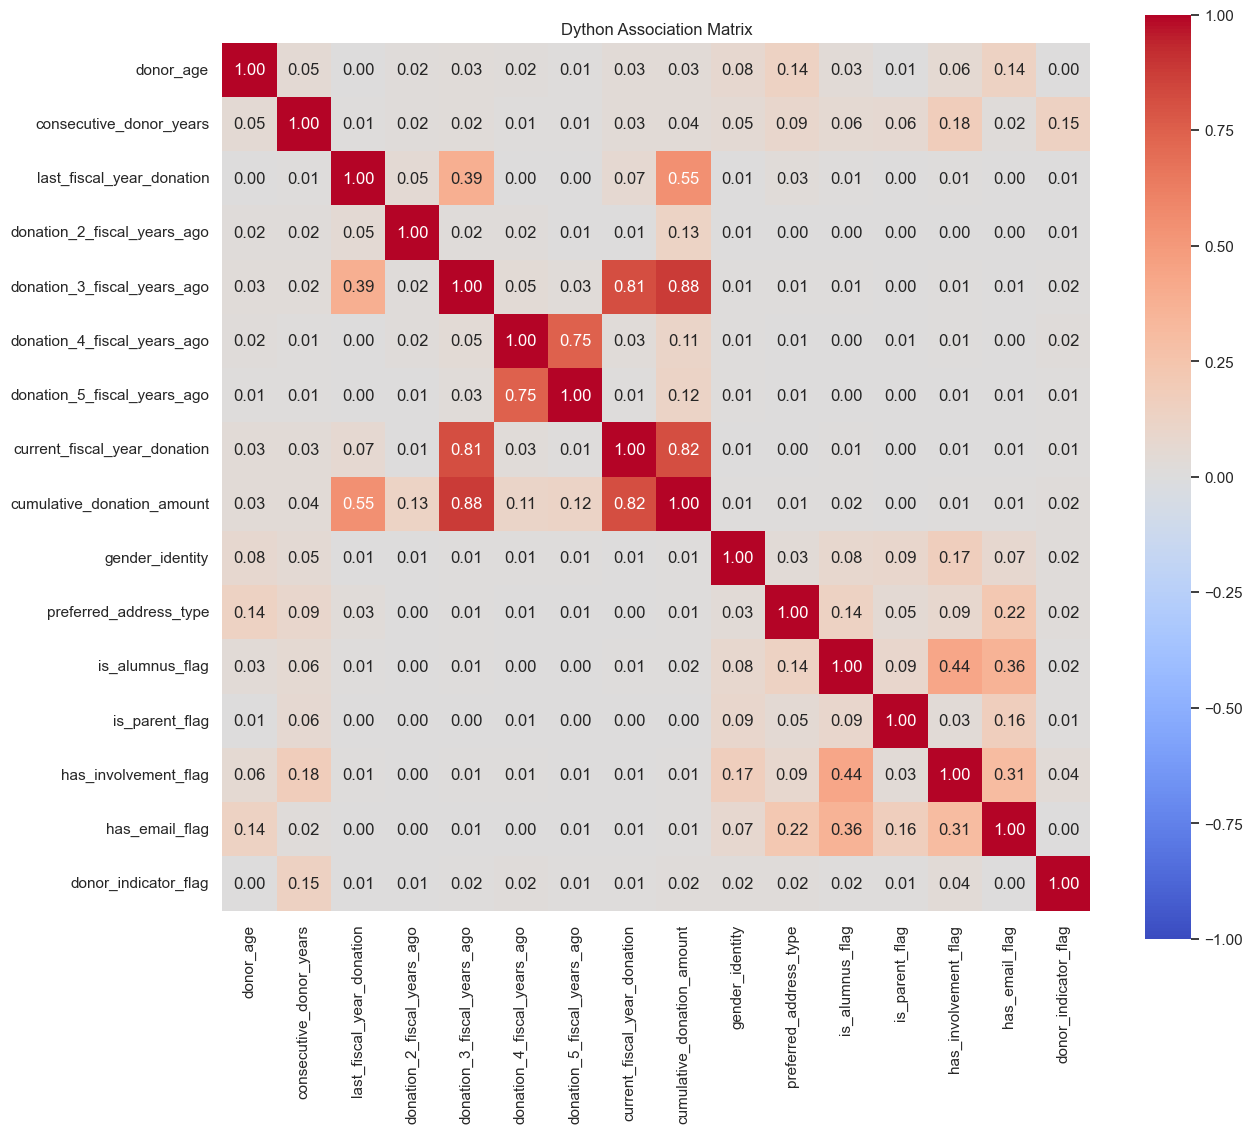

In [13]:
# Create Dython association matrix
association_results = associations(
    association_df,
    nominal_columns=categorical_features + binary_features + target_feature,
    figsize=(14, 12),
    cmap="coolwarm",
    title="Dython Association Matrix",
    clustering=False,
    nan_strategy="replace",
    nan_replace_value="Missing"
)

In [14]:
# Display the correlation matrix
association_matrix = association_results["corr"]

association_matrix

,donor_age,consecutive_donor_years,last_fiscal_year_donation,donation_2_fiscal_years_ago,donation_3_fiscal_years_ago,donation_4_fiscal_years_ago,donation_5_fiscal_years_ago,current_fiscal_year_donation,cumulative_donation_amount,gender_identity,preferred_address_type,is_alumnus_flag,is_parent_flag,has_involvement_flag,has_email_flag,donor_indicator_flag
donor_age,1.000000,0.049618,0.002854,0.021981,0.028051,0.016955,0.013613,0.032794,0.031465,0.076968,0.135177,0.033379,0.006013,0.061315,0.135970,0.001757
consecutive_donor_years,0.049618,1.000000,0.011967,0.016613,0.024178,0.012232,0.014793,0.032918,0.039034,0.053278,0.092522,0.058656,0.063570,0.178617,0.017178,0.147963
last_fiscal_year_donation,0.002854,0.011967,1.000000,0.050901,0.388045,0.004393,0.002278,0.070240,0.546359,0.006280,0.031228,0.010270,0.001717,0.009882,0.004361,0.005465
donation_2_fiscal_years_ago,0.021981,0.016613,0.050901,1.000000,0.021612,0.017216,0.006616,0.007489,0.129662,0.005173,0.002851,0.003315,0.000781,0.003404,0.003699,0.007196
donation_3_fiscal_years_ago,0.028051,0.024178,0.388045,0.021612,1.000000,0.045495,0.026824,0.814676,0.875629,0.008428,0.008988,0.012031,0.000461,0.007955,0.006777,0.015190
donation_4_fiscal_years_ago,0.016955,0.012232,0.004393,0.017216,0.045495,1.000000,0.745792,0.030951,0.112313,0.013113,0.005429,0.000607,0.007468,0.011901,0.004532,0.017215
donation_5_fiscal_years_ago,0.013613,0.014793,0.002278,0.006616,0.026824,0.745792,1.000000,0.010389,0.118068,0.009068,0.007722,0.002269,0.000563,0.007671,0.005372,0.009841
current_fiscal_year_donation,0.032794,0.032918,0.070240,0.007489,0.814676,0.030951,0.010389,1.000000,0.815303,0.005438,0.003256,0.011347,0.002126,0.005489,0.006904,0.009756
cumulative_donation_amount,0.031465,0.039034,0.546359,0.129662,0.875629,0.112313,0.118068,0.815303,1.000000,0.008026,0.013374,0.015118,0.002297,0.010170,0.007952,0.016237
gender_identity,0.076968,0.053278,0.006280,0.005173,0.008428,0.013113,0.009068,0.005438,0.008026,1.000000,0.034377,0.083451,0.087789,0.165009,0.070500,0.021272


In [15]:
# Verify association matrix shape
print(f"Association Matrix Shape: {association_matrix.shape}")

Association Matrix Shape: (16, 16)


In [16]:
# Preview strongest associations overall
association_matrix_abs = association_matrix.abs()

upper_triangle = association_matrix_abs.where(
    np.triu(np.ones(association_matrix_abs.shape), k=1).astype(bool)
)

strong_pairs = (
    upper_triangle
    .stack()
    .sort_values(ascending=False)
    .reset_index()
)

strong_pairs.columns = ["Variable 1", "Variable 2", "Association"]

strong_pairs.head(20).style.hide(axis="index")

Variable 1,Variable 2,Association
donation_3_fiscal_years_ago,cumulative_donation_amount,0.875629
current_fiscal_year_donation,cumulative_donation_amount,0.815303
donation_3_fiscal_years_ago,current_fiscal_year_donation,0.814676
donation_4_fiscal_years_ago,donation_5_fiscal_years_ago,0.745792
last_fiscal_year_donation,cumulative_donation_amount,0.546359
is_alumnus_flag,has_involvement_flag,0.436301
last_fiscal_year_donation,donation_3_fiscal_years_ago,0.388045
is_alumnus_flag,has_email_flag,0.364516
has_involvement_flag,has_email_flag,0.307810
preferred_address_type,has_email_flag,0.222440


### Association Matrix Summary

The full Dython association matrix was successfully generated for the 16 selected analytical variables, capturing relationships across numerical, categorical, binary, and historical donor behavior metrics.

- The strongest associations are concentrated among the donation history variables, particularly `cumulative_donation_amount`, `donation_3_fiscal_years_ago`, and `current_fiscal_year_donation`.
  - These strong correlations indicate that several giving-related variables capture closely related aspects of historical behavior and likely contain overlapping information.
- Moderate associations also appear among the engagement variables, including `is_alumnus_flag`, `has_involvement_flag`, and `has_email_flag`.
  - This pattern suggests that donors with stronger institutional ties often share multiple forms of involvement.
- In contrast, demographic variables such as `donor_age`, `gender_identity`, and `preferred_address_type` generally show much weaker associations with the rest of the dataset.

Ultimately, the matrix reveals that historical giving behavior is the dominant source of information here, while engagement indicators provide complementary insights into donor characteristics.

In [17]:
# Donation history variables
donation_features = [
    "consecutive_donor_years",
    "last_fiscal_year_donation",
    "donation_2_fiscal_years_ago",
    "donation_3_fiscal_years_ago",
    "donation_4_fiscal_years_ago",
    "donation_5_fiscal_years_ago",
    "current_fiscal_year_donation",
    "cumulative_donation_amount"
]

In [18]:
# Extract donation related variables of the full association matrix
donation_association_matrix = association_matrix.loc[
    donation_features,
    donation_features
]

donation_association_matrix

,consecutive_donor_years,last_fiscal_year_donation,donation_2_fiscal_years_ago,donation_3_fiscal_years_ago,donation_4_fiscal_years_ago,donation_5_fiscal_years_ago,current_fiscal_year_donation,cumulative_donation_amount
consecutive_donor_years,1.000000,0.011967,0.016613,0.024178,0.012232,0.014793,0.032918,0.039034
last_fiscal_year_donation,0.011967,1.000000,0.050901,0.388045,0.004393,0.002278,0.070240,0.546359
donation_2_fiscal_years_ago,0.016613,0.050901,1.000000,0.021612,0.017216,0.006616,0.007489,0.129662
donation_3_fiscal_years_ago,0.024178,0.388045,0.021612,1.000000,0.045495,0.026824,0.814676,0.875629
donation_4_fiscal_years_ago,0.012232,0.004393,0.017216,0.045495,1.000000,0.745792,0.030951,0.112313
donation_5_fiscal_years_ago,0.014793,0.002278,0.006616,0.026824,0.745792,1.000000,0.010389,0.118068
current_fiscal_year_donation,0.032918,0.070240,0.007489,0.814676,0.030951,0.010389,1.000000,0.815303
cumulative_donation_amount,0.039034,0.546359,0.129662,0.875629,0.112313,0.118068,0.815303,1.000000


In [19]:
# Ranked table of strongest associations among donation variables
donation_pairs = (
    donation_association_matrix.abs()
    .where(
        np.triu(
            np.ones(donation_association_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .dropna()
    .sort_values(ascending=False)
    .reset_index()
)

donation_pairs.columns = [
    "Donation Variable 1",
    "Donation Variable 2",
    "Association"
]

donation_pairs.style.hide(axis="index")

Donation Variable 1,Donation Variable 2,Association
donation_3_fiscal_years_ago,cumulative_donation_amount,0.875629
current_fiscal_year_donation,cumulative_donation_amount,0.815303
donation_3_fiscal_years_ago,current_fiscal_year_donation,0.814676
donation_4_fiscal_years_ago,donation_5_fiscal_years_ago,0.745792
last_fiscal_year_donation,cumulative_donation_amount,0.546359
last_fiscal_year_donation,donation_3_fiscal_years_ago,0.388045
donation_2_fiscal_years_ago,cumulative_donation_amount,0.129662
donation_5_fiscal_years_ago,cumulative_donation_amount,0.118068
donation_4_fiscal_years_ago,cumulative_donation_amount,0.112313
last_fiscal_year_donation,current_fiscal_year_donation,0.070240


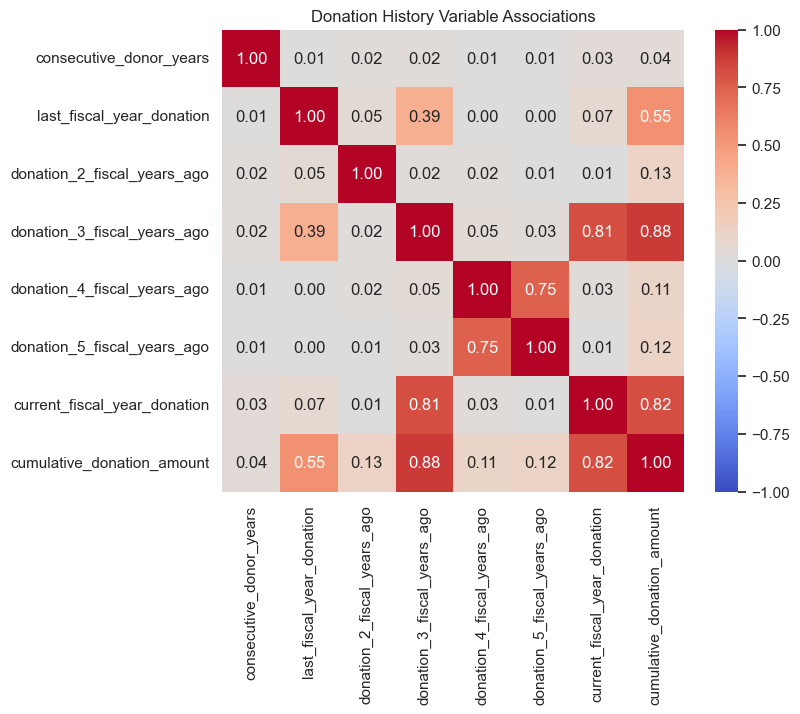

In [20]:
# Donation heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    donation_association_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True
)

plt.title("Donation History Variable Associations")
plt.show()

In [21]:
# Strong donation variable associations (>= 0.70)
strong_donation_pairs = donation_pairs[
    donation_pairs["Association"] >= REDUNDANCY_THRESHOLD
]

strong_donation_pairs.style.hide(axis="index")

Donation Variable 1,Donation Variable 2,Association
donation_3_fiscal_years_ago,cumulative_donation_amount,0.875629
current_fiscal_year_donation,cumulative_donation_amount,0.815303
donation_3_fiscal_years_ago,current_fiscal_year_donation,0.814676
donation_4_fiscal_years_ago,donation_5_fiscal_years_ago,0.745792


### Donation History Summary

The donation history variables exhibit the strongest associations observed throughout the dataset, indicating that several variables capture closely related aspects of historical giving behavior.

- The strongest association is observed between `donation_3_fiscal_years_ago` and `cumulative_donation_amount` (0.876), followed closely by the relationships between `current_fiscal_year_donation` and both `cumulative_donation_amount` (0.815) and `donation_3_fiscal_years_ago` (0.815).
  - These findings suggest that cumulative giving is strongly influenced by recent donation activity.
- Another notable relationship exists between `donation_4_fiscal_years_ago` and `donation_5_fiscal_years_ago` (0.746), indicating consistent donation patterns across consecutive fiscal years.
- Despite representing long-term donor commitment, `consecutive_donor_years` exhibits only weak associations with donation amount variables (all associations below 0.04), suggesting that donor longevity and donation magnitude capture different aspects of donor behavior.

Overall, the results indicate that several donation history variables contain overlapping information and should be evaluated for redundancy during feature engineering.

In [22]:
# Demographic and engagement variables
demographic_engagement_features = [
    "donor_age",
    "gender_identity",
    "preferred_address_type",
    "is_alumnus_flag",
    "is_parent_flag",
    "has_involvement_flag",
    "has_email_flag"
]

In [23]:
# Extract demographic engagement association matrix
demographic_engagement_matrix = association_matrix.loc[
    demographic_engagement_features,
    demographic_engagement_features
]

demographic_engagement_matrix

,donor_age,gender_identity,preferred_address_type,is_alumnus_flag,is_parent_flag,has_involvement_flag,has_email_flag
donor_age,1.000000,0.076968,0.135177,0.033379,0.006013,0.061315,0.135970
gender_identity,0.076968,1.000000,0.034377,0.083451,0.087789,0.165009,0.070500
preferred_address_type,0.135177,0.034377,1.000000,0.137830,0.048006,0.085323,0.222440
is_alumnus_flag,0.033379,0.083451,0.137830,1.000000,0.087844,0.436301,0.364516
is_parent_flag,0.006013,0.087789,0.048006,0.087844,1.000000,0.031276,0.164308
has_involvement_flag,0.061315,0.165009,0.085323,0.436301,0.031276,1.000000,0.307810
has_email_flag,0.135970,0.070500,0.222440,0.364516,0.164308,0.307810,1.000000


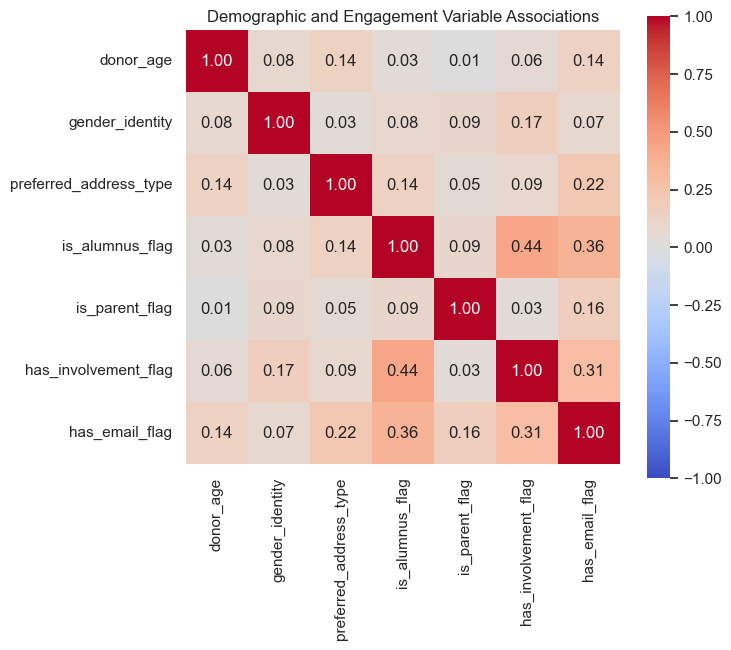

In [24]:
# Demographic and engagement heatmap
plt.figure(figsize=(7, 6))

sns.heatmap(
    demographic_engagement_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True
)

plt.title("Demographic and Engagement Variable Associations")
plt.show()

In [25]:
# Rank strongest association for demographic engagement
demographic_engagement_pairs = (
    demographic_engagement_matrix.abs()
    .where(
        np.triu(
            np.ones(demographic_engagement_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .dropna()
    .sort_values(ascending=False)
    .reset_index()
)

demographic_engagement_pairs.columns = [
    "Variable 1",
    "Variable 2",
    "Association"
]

demographic_engagement_pairs.style.hide(axis="index")

Variable 1,Variable 2,Association
is_alumnus_flag,has_involvement_flag,0.436301
is_alumnus_flag,has_email_flag,0.364516
has_involvement_flag,has_email_flag,0.307810
preferred_address_type,has_email_flag,0.222440
gender_identity,has_involvement_flag,0.165009
is_parent_flag,has_email_flag,0.164308
preferred_address_type,is_alumnus_flag,0.137830
donor_age,has_email_flag,0.135970
donor_age,preferred_address_type,0.135177
is_alumnus_flag,is_parent_flag,0.087844


In [26]:
# Display associations of at least 0.15
notable_demographic_engagement = demographic_engagement_pairs[
    demographic_engagement_pairs["Association"] >= 0.15
]

notable_demographic_engagement.style.hide(axis="index")

Variable 1,Variable 2,Association
is_alumnus_flag,has_involvement_flag,0.436301
is_alumnus_flag,has_email_flag,0.364516
has_involvement_flag,has_email_flag,0.307810
preferred_address_type,has_email_flag,0.222440
gender_identity,has_involvement_flag,0.165009
is_parent_flag,has_email_flag,0.164308


### Demographic and Engagement Summary
Compared to the donation history variables, demographic and engagement variables exhibit generally weaker associations. However, the engagement indicators display stronger relationships with one another than the demographic characteristics.
- The strongest association is observed between `is_alumnus_flag` and `has_involvement_flag` (0.436), suggesting that alumni are more likely to have additional involvement with the organization.
- Moderate associations are also observed between `is_alumnus_flag` and `has_email_flag` (0.365) and between `has_involvement_flag` and `has_email_flag` (0.308), indicating that engaged donors often share multiple forms of institutional engagement.
- Among the demographic variables, `preferred_address_type` exhibits the strongest relationship with another feature through its association with `has_email_flag` (0.222).
- In contrast, `donor_age` and `gender_identity` demonstrate relatively weak associations with the remaining variables.

Overall, these findings suggest that engagement indicators provide more meaningful complementary information than demographic characteristics. 

In [27]:
# Feature pairs with high association (>= 0.70)
redundant_features = strong_pairs[
    strong_pairs["Association"] >= REDUNDANCY_THRESHOLD
].copy()

redundant_features.style.hide(axis="index")

Variable 1,Variable 2,Association
donation_3_fiscal_years_ago,cumulative_donation_amount,0.875629
current_fiscal_year_donation,cumulative_donation_amount,0.815303
donation_3_fiscal_years_ago,current_fiscal_year_donation,0.814676
donation_4_fiscal_years_ago,donation_5_fiscal_years_ago,0.745792


In [28]:
# Categorize redundancy level function
def redundancy_note(value):
    if value >= 0.85:
        return "Very high association; evaluate for potential redundancy."
    elif value >= 0.80:
        return "High association; consider during feature engineering."
    else:
        return "Moderate-to-high association; monitor during modeling."

In [29]:
# Categorize redundancy level
redundant_features["Notes"] = (
    redundant_features["Association"]
    .apply(redundancy_note)
)

redundant_features.style.hide(axis="index")

Variable 1,Variable 2,Association,Notes
donation_3_fiscal_years_ago,cumulative_donation_amount,0.875629,Very high association; evaluate for potential redundancy.
current_fiscal_year_donation,cumulative_donation_amount,0.815303,High association; consider during feature engineering.
donation_3_fiscal_years_ago,current_fiscal_year_donation,0.814676,High association; consider during feature engineering.
donation_4_fiscal_years_ago,donation_5_fiscal_years_ago,0.745792,Moderate-to-high association; monitor during modeling.


### Feature Redundancy Summary

Several donation history variables exhibit strong associations, indicating that they capture overlapping aspects of historical giving behavior. The highest associations are observed between
- `donation_3_fiscal_years_ago` and `cumulative_donation_amount` (0.876)
- `current_fiscal_year_donation` and `cumulative_donation_amount` (0.815) 
- `current_fiscal_year_donation` and `donation_3_fiscal_years_ago` (0.815).

These findings suggest that some donation variables may contain redundant information and should be evaluated during feature engineering. However, strong associations alone do not justify removing variables, as each may capture a distinct aspect of donor behavior.

Although strong Dython associations indicate that variables share similar information, they do not directly measure multicollinearity. These results should be treated as an exploratory indicator of potential redundancy and validated further during the modeling phase using techniques such as Variance Inflation Factor (VIF) or feature importance analysis.

Outside of the donation history variables, no demographic or engagement features exhibit associations strong enough to suggest substantial redundancy.

## EDA Validation and Association Matrix Confirmation

| Phase 2 EDA Observation                                                                      | Phase 3 Dython Confirmation                                                                                                                                                       |
| -------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Historical donation variables exhibited strong relationships and right-skewed distributions. | Strong associations were observed among donation history variables, particularly `cumulative_donation_amount`, `donation_3_fiscal_years_ago`, and `current_fiscal_year_donation`. |
| Historical giving appeared to be the most informative aspect of donor behavior.              | Donation history variables formed the strongest association cluster in the dataset, confirming their importance.                                                                  |
| Engagement indicators appeared more informative than demographic characteristics.            | Moderate associations among `is_alumnus_flag`, `has_involvement_flag`, and `has_email_flag` support this observation.                                                             |
| Demographic variables showed relatively weak patterns during EDA.                            | Demographic variables generally exhibited weak associations with other variables, reinforcing the EDA findings.                                                                   |
| Several donation-related variables appeared likely to overlap conceptually.                  | Strong associations among donation history variables indicate potential redundancy to investigate during feature engineering.                                                     |


### Confirmed Findings

The Dython association analysis largely confirmed the major observations identified during Phase 2 Exploratory Data Analysis. Historical donation variables remained the strongest source of information within the dataset, while engagement indicators demonstrated stronger relationships than demographic characteristics.

The association analysis also reinforced the observation that several donation history variables describe similar aspects of donor behavior, suggesting that they should be evaluated further during feature engineering.

### New Insights

While the EDA primarily focused on individual variable distributions and relationships with historical donor behavior, the Dython analysis quantified the strength of relationships between variables. In particular, the association matrix highlighted several highly associated donation history feature pairs and identified a moderate cluster among engagement indicators.

These statistical associations provide additional evidence for evaluating feature redundancy and identifying opportunities for feature engineering in subsequent phases.

### Comparison Summary

The Dython association analysis supports the key conclusions reached during Phase 2 Exploratory Data Analysis. No major contradictions were identified between the two analyses. Instead, Dython provided quantitative evidence that reinforced previous observations regarding the importance of donation history variables, the complementary value of engagement indicators, and the relatively limited relationships among demographic characteristics.

Together, the findings from Phases 2 and 3 provide a strong foundation for feature engineering and predictive modeling.